# IMDB: SVD Attention Rank Study
Outputs below are preserved historical results, not a rerun of this portable copy. See ../docs/REPRODUCIBILITY.md.

In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "HodaDatasetReader.py").exists())
sys.path.insert(0, str(ROOT / "src"))
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


## **Import**

In [ ]:
# Install dependencies once using requirements.txt.

In [ ]:
import os
import time
import math
import warnings
import psutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.linalg as linalg
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from transformers import BertTokenizer

warnings.filterwarnings('ignore')


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Load dataset**

In [ ]:
dataset = load_dataset("imdb")
train_data = dataset["train"]
test_data = dataset["test"]

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## **Tokenize the input**

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
max_seq_length = 512

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=max_seq_length,
        return_tensors="pt"
    )

In [ ]:
train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)
# Output: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

## **Convert to Pytorch tensors**

In [ ]:
columns = ["input_ids", "attention_mask", "label"]
train_data.set_format(type="torch", columns=columns)
test_data.set_format(type="torch", columns=columns)

## **Prepare DataLoaders**

In [ ]:
batch_size= 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# **Model:**

## **Self-Attention**
Define a class for Multi-Head Attention with Low-Rank SVD Decomposition

In [ ]:
class CustomSelfAttention(nn.Module):
    def __init__(self, embed_size, heads, lowRank):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.lowRank = lowRank
        self.head_dim = embed_size // heads

        # Initialize weights
        W_q_full = nn.Linear(embed_size, embed_size, bias=False)
        W_k_full = nn.Linear(embed_size, embed_size, bias=False)
        W_v_full = nn.Linear(embed_size, embed_size, bias=False)

        # Freeze
        for param in W_q_full.parameters():
            param.requires_grad = False
        for param in W_k_full.parameters():
            param.requires_grad = False
        for param in W_v_full.parameters():
            param.requires_grad = False

        # Perform SVD on weights
        with torch.no_grad():
            U_q, S_q, V_q = linalg.svd(W_q_full.weight, full_matrices=False)
            U_k, S_k, V_k = linalg.svd(W_k_full.weight, full_matrices=False)
            U_v, S_v, V_v = linalg.svd(W_v_full.weight, full_matrices=False)

        #  Perform truncated SVD
        U_q, S_q, V_q = U_q[:, :lowRank], torch.diag(S_q[:lowRank]), V_q[:lowRank, :]
        U_k, S_k, V_k = U_k[:, :lowRank], torch.diag(S_k[:lowRank]), V_k[:lowRank, :]
        U_v, S_v, V_v = U_v[:, :lowRank], torch.diag(S_v[:lowRank]), V_v[:lowRank, :]

        # Treat SVD as parameters
        self.U_q = nn.Parameter(U_q)
        self.S_q = nn.Parameter(S_q)
        self.V_q = nn.Parameter(V_q)

        self.U_k = nn.Parameter(U_k)
        self.S_k = nn.Parameter(S_k)
        self.V_k = nn.Parameter(V_k)

        self.U_v = nn.Parameter(U_v)
        self.S_v = nn.Parameter(S_v)
        self.V_v = nn.Parameter(V_v)

    def forward(self, value, key, query, mask=None):
        batch_size = query.shape[0]

        # Reconstruct weights by SVD
        W_q = self.U_q @ self.S_q @ self.V_q
        W_k = self.U_k @ self.S_k @ self.V_k
        W_v = self.U_v @ self.S_v @ self.V_v

        # reshape for multiple heads
        Q = torch.matmul(query, W_q.T).view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
        K = torch.matmul(key, W_k.T).view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)
        V = torch.matmul(value, W_v.T).view(batch_size, -1, self.heads, self.head_dim).transpose(1, 2)

        # Compute attention scores
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float("-inf"))

        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        output = torch.matmul(attention_probs, V)

        # Reshape output back to original shape
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_size)
        return output


## **Tansformer block**
Define a transformer block (attention,norms,...)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, lowRank, dropout=0.1):
        super(TransformerBlock, self).__init__()

        self.attention = CustomSelfAttention(embed_dim, num_heads, lowRank)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output = self.attention(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

## **Positional Encoding**
Define a class to perform positional encoding. Sinusoidal positional encoding is recommended.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_seq_length):
        super(PositionalEncoding, self).__init__()

        # shape (max_seq_length, embed_dim)
        pos = torch.arange(0, max_seq_length).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))

        pe = torch.zeros(max_seq_length, embed_dim)
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        self.register_buffer("positional_encoding", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.positional_encoding[:, :x.shape[1], :]

## **Transformer model**
Define transformer class bringing all components together.

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_seq_length, lowRank, dropout=0.2):
        super(TransformerClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_seq_length)
        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads, ff_dim, lowRank, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size, seq_length = x.shape
        x = self.embedding(x)
        x = self.positional_encoding(x)

        for transformer in self.transformer_blocks:
            x = transformer(x)
        x = x.mean(dim=1)
        output = self.fc(x)
        return output

## **Training and evaluation**

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    model.train()
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        total_loss = 0
        correct_train = 0
        total_train = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        train_accuracy = correct_train / total_train * 100
        train_accuracies.append(train_accuracy)

        test_accuracy, avg_test_loss, _, _ = evaluate_model(model, test_loader, criterion, device)
        test_accuracies.append(test_accuracy)
        test_losses.append(avg_test_loss)

        scheduler.step(avg_test_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | "
              f"Train Accuracy: {train_accuracy:.2f}% | Test Accuracy: {test_accuracy:.2f}%")

    return train_losses, test_losses, train_accuracies, test_accuracies

In [ ]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total * 100
    avg_loss = total_loss / len(test_loader)
    return accuracy, avg_loss, all_labels, all_preds

In [ ]:
def plot_confusion_matrix(true_labels, pred_labels, class_names):
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

class_names = ["Negative", "Positive"]

In [ ]:
def plot_learning_curve(train_losses, test_losses, train_accuracies, test_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    # Plot loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Plot accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, test_accuracies, label="Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.show()

## Training

In [ ]:
vocab_size = tokenizer.vocab_size
embed_dim = 128
num_heads = 4
ff_dim = 512
num_layers = 1
num_classes = 2
max_seq_length = 512
dropout = 0.2
num_epochs = 10


  Training with lowRank = 1
Epoch 1/10 | Train Loss: 0.6970 | Test Loss: 0.6929 | Train Accuracy: 50.33% | Test Accuracy: 50.63%
Epoch 2/10 | Train Loss: 0.6931 | Test Loss: 0.6930 | Train Accuracy: 50.49% | Test Accuracy: 50.14%
Epoch 3/10 | Train Loss: 0.6917 | Test Loss: 0.6911 | Train Accuracy: 52.32% | Test Accuracy: 53.78%
Epoch 4/10 | Train Loss: 0.6907 | Test Loss: 0.6903 | Train Accuracy: 54.01% | Test Accuracy: 55.77%
Epoch 5/10 | Train Loss: 0.6896 | Test Loss: 0.6890 | Train Accuracy: 55.05% | Test Accuracy: 56.29%
Epoch 6/10 | Train Loss: 0.6882 | Test Loss: 0.6878 | Train Accuracy: 56.54% | Test Accuracy: 57.70%
Epoch 7/10 | Train Loss: 0.6868 | Test Loss: 0.6868 | Train Accuracy: 57.04% | Test Accuracy: 57.05%
Epoch 8/10 | Train Loss: 0.6849 | Test Loss: 0.6864 | Train Accuracy: 58.47% | Test Accuracy: 54.61%
Epoch 9/10 | Train Loss: 0.6835 | Test Loss: 0.6834 | Train Accuracy: 58.31% | Test Accuracy: 59.29%
Epoch 10/10 | Train Loss: 0.6814 | Test Loss: 0.6818 | Train A

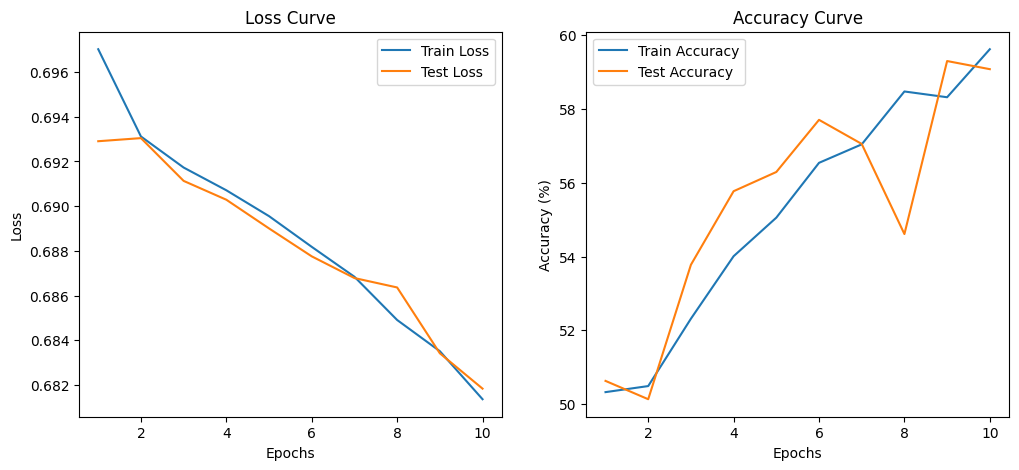

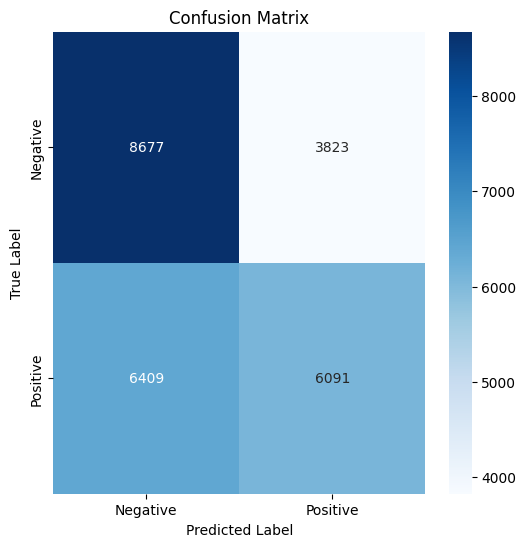


  Training with lowRank = 5
Epoch 1/10 | Train Loss: 0.6940 | Test Loss: 0.6928 | Train Accuracy: 49.84% | Test Accuracy: 50.69%
Epoch 2/10 | Train Loss: 0.6927 | Test Loss: 0.6923 | Train Accuracy: 51.59% | Test Accuracy: 50.72%
Epoch 3/10 | Train Loss: 0.6918 | Test Loss: 0.6913 | Train Accuracy: 52.50% | Test Accuracy: 54.36%
Epoch 4/10 | Train Loss: 0.6911 | Test Loss: 0.6904 | Train Accuracy: 52.83% | Test Accuracy: 55.09%
Epoch 5/10 | Train Loss: 0.6899 | Test Loss: 0.6903 | Train Accuracy: 54.15% | Test Accuracy: 53.09%
Epoch 6/10 | Train Loss: 0.6887 | Test Loss: 0.6887 | Train Accuracy: 55.45% | Test Accuracy: 55.60%
Epoch 7/10 | Train Loss: 0.6872 | Test Loss: 0.6874 | Train Accuracy: 56.83% | Test Accuracy: 56.34%
Epoch 8/10 | Train Loss: 0.6860 | Test Loss: 0.6860 | Train Accuracy: 57.54% | Test Accuracy: 58.19%
Epoch 9/10 | Train Loss: 0.6843 | Test Loss: 0.6861 | Train Accuracy: 58.30% | Test Accuracy: 53.96%
Epoch 10/10 | Train Loss: 0.6827 | Test Loss: 0.6841 | Train A

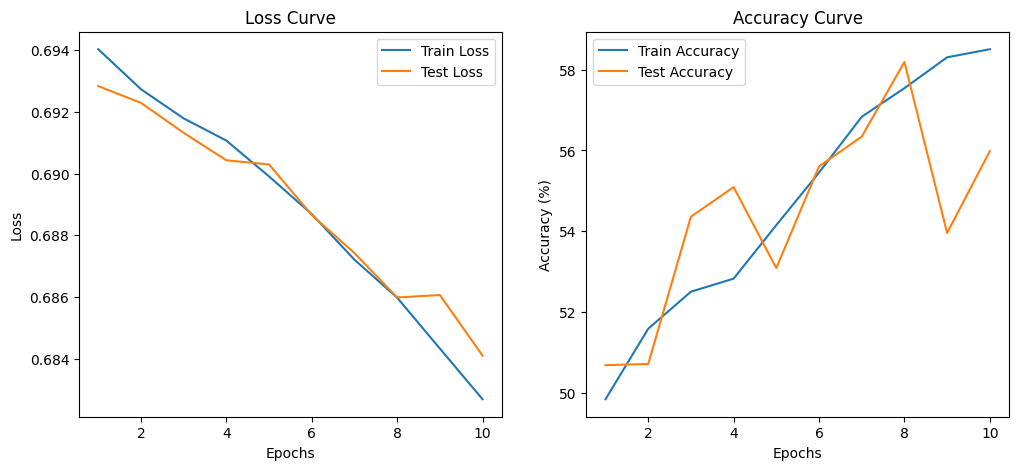

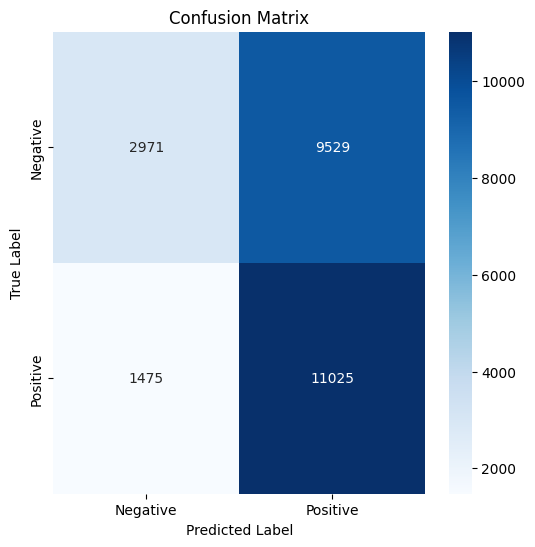


  Training with lowRank = 10
Epoch 1/10 | Train Loss: 0.6969 | Test Loss: 0.6930 | Train Accuracy: 49.71% | Test Accuracy: 49.84%
Epoch 2/10 | Train Loss: 0.6929 | Test Loss: 0.6922 | Train Accuracy: 50.52% | Test Accuracy: 51.13%
Epoch 3/10 | Train Loss: 0.6920 | Test Loss: 0.6914 | Train Accuracy: 52.22% | Test Accuracy: 52.50%
Epoch 4/10 | Train Loss: 0.6911 | Test Loss: 0.6907 | Train Accuracy: 53.43% | Test Accuracy: 56.00%
Epoch 5/10 | Train Loss: 0.6900 | Test Loss: 0.6895 | Train Accuracy: 55.19% | Test Accuracy: 56.60%
Epoch 6/10 | Train Loss: 0.6886 | Test Loss: 0.6885 | Train Accuracy: 55.33% | Test Accuracy: 57.24%
Epoch 7/10 | Train Loss: 0.6877 | Test Loss: 0.6877 | Train Accuracy: 55.90% | Test Accuracy: 54.97%
Epoch 8/10 | Train Loss: 0.6861 | Test Loss: 0.6860 | Train Accuracy: 56.83% | Test Accuracy: 58.18%
Epoch 9/10 | Train Loss: 0.6849 | Test Loss: 0.6857 | Train Accuracy: 56.52% | Test Accuracy: 54.70%
Epoch 10/10 | Train Loss: 0.6832 | Test Loss: 0.6837 | Train 

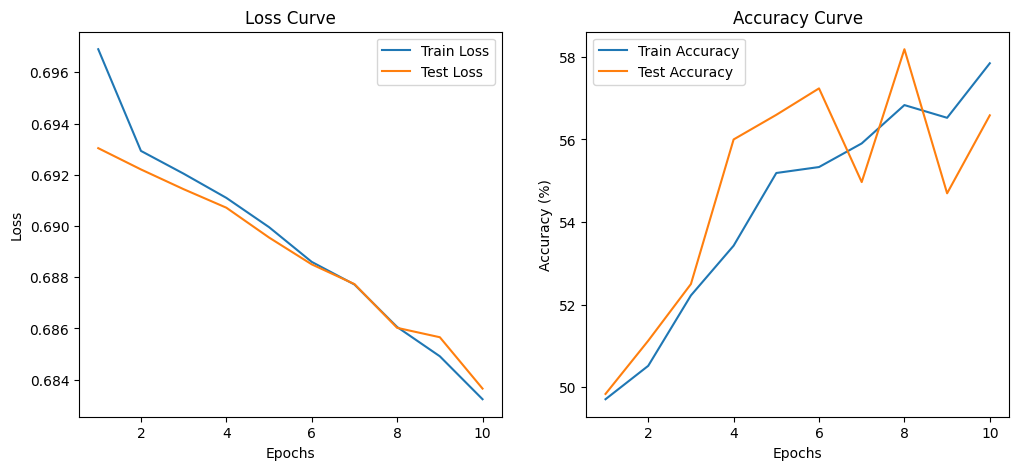

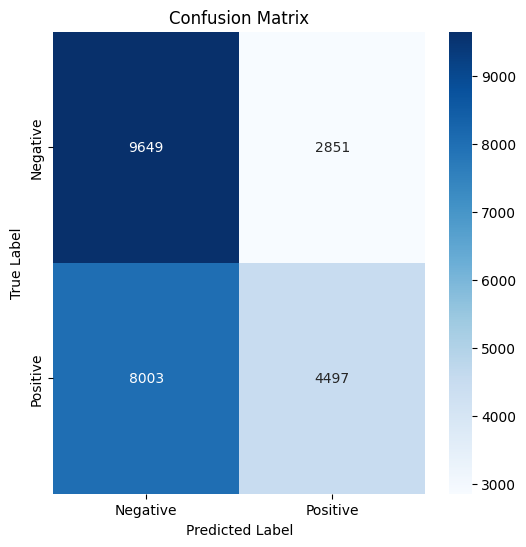


  Training with lowRank = 15
Epoch 1/10 | Train Loss: 0.6935 | Test Loss: 0.6918 | Train Accuracy: 51.41% | Test Accuracy: 52.96%
Epoch 2/10 | Train Loss: 0.6914 | Test Loss: 0.6915 | Train Accuracy: 52.94% | Test Accuracy: 51.49%
Epoch 3/10 | Train Loss: 0.6902 | Test Loss: 0.6900 | Train Accuracy: 54.65% | Test Accuracy: 54.50%
Epoch 4/10 | Train Loss: 0.6890 | Test Loss: 0.6890 | Train Accuracy: 55.66% | Test Accuracy: 56.52%
Epoch 5/10 | Train Loss: 0.6875 | Test Loss: 0.6884 | Train Accuracy: 56.34% | Test Accuracy: 53.40%
Epoch 6/10 | Train Loss: 0.6859 | Test Loss: 0.6855 | Train Accuracy: 56.79% | Test Accuracy: 57.54%
Epoch 7/10 | Train Loss: 0.6823 | Test Loss: 0.6815 | Train Accuracy: 58.16% | Test Accuracy: 57.89%
Epoch 8/10 | Train Loss: 0.6761 | Test Loss: 0.6732 | Train Accuracy: 58.81% | Test Accuracy: 59.41%
Epoch 9/10 | Train Loss: 0.6618 | Test Loss: 0.6573 | Train Accuracy: 61.48% | Test Accuracy: 61.63%
Epoch 10/10 | Train Loss: 0.6496 | Test Loss: 0.6403 | Train 

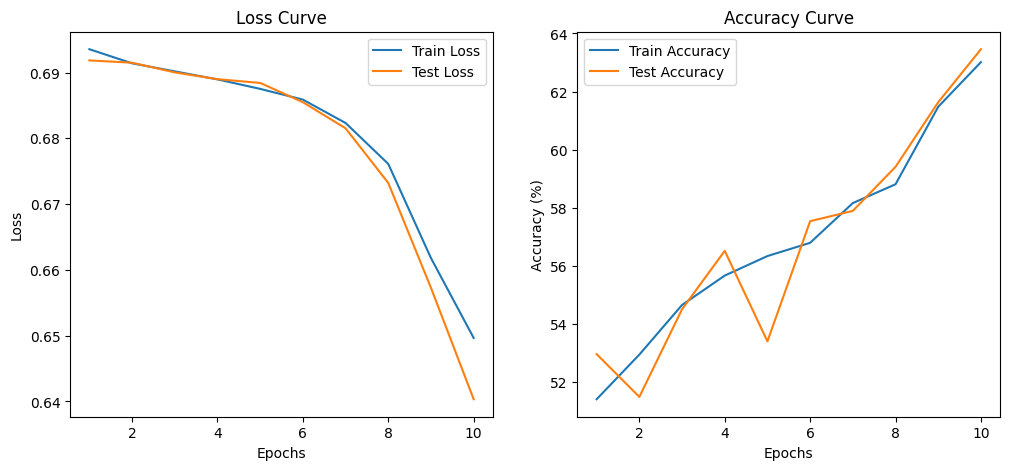

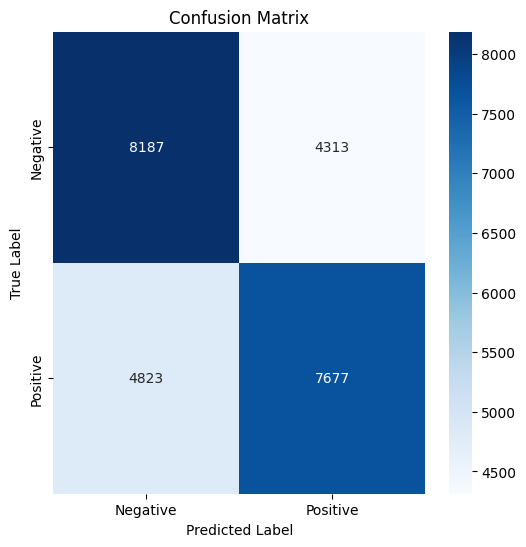


  Training with lowRank = 20
Epoch 1/10 | Train Loss: 0.6946 | Test Loss: 0.6934 | Train Accuracy: 48.71% | Test Accuracy: 49.48%
Epoch 2/10 | Train Loss: 0.6931 | Test Loss: 0.6923 | Train Accuracy: 50.74% | Test Accuracy: 52.18%
Epoch 3/10 | Train Loss: 0.6916 | Test Loss: 0.6913 | Train Accuracy: 52.63% | Test Accuracy: 53.22%
Epoch 4/10 | Train Loss: 0.6905 | Test Loss: 0.6902 | Train Accuracy: 53.70% | Test Accuracy: 53.22%
Epoch 5/10 | Train Loss: 0.6886 | Test Loss: 0.6885 | Train Accuracy: 55.53% | Test Accuracy: 56.31%
Epoch 6/10 | Train Loss: 0.6866 | Test Loss: 0.6868 | Train Accuracy: 56.54% | Test Accuracy: 56.86%
Epoch 7/10 | Train Loss: 0.6841 | Test Loss: 0.6878 | Train Accuracy: 57.67% | Test Accuracy: 53.59%
Epoch 8/10 | Train Loss: 0.6813 | Test Loss: 0.6817 | Train Accuracy: 58.38% | Test Accuracy: 57.98%
Epoch 9/10 | Train Loss: 0.6768 | Test Loss: 0.6778 | Train Accuracy: 59.80% | Test Accuracy: 59.36%
Epoch 10/10 | Train Loss: 0.6687 | Test Loss: 0.6662 | Train 

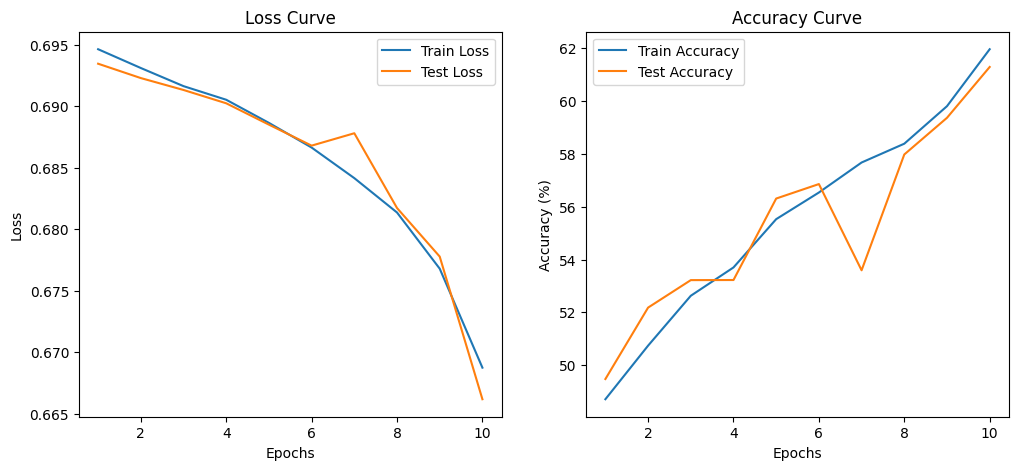

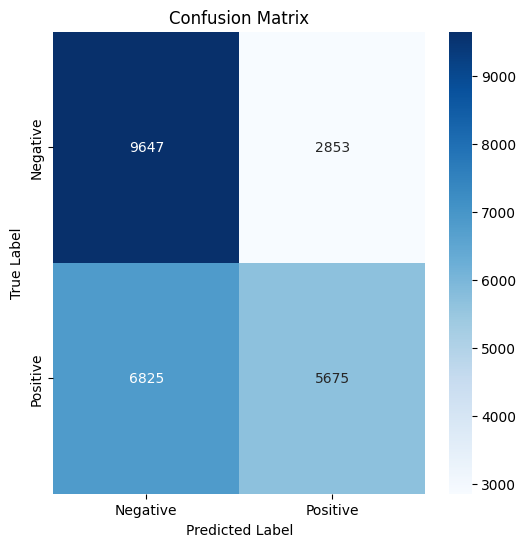


  Training with lowRank = 35
Epoch 1/10 | Train Loss: 0.6922 | Test Loss: 0.6920 | Train Accuracy: 51.80% | Test Accuracy: 51.26%
Epoch 2/10 | Train Loss: 0.6907 | Test Loss: 0.6906 | Train Accuracy: 53.13% | Test Accuracy: 54.06%
Epoch 3/10 | Train Loss: 0.6891 | Test Loss: 0.6891 | Train Accuracy: 55.17% | Test Accuracy: 55.57%
Epoch 4/10 | Train Loss: 0.6875 | Test Loss: 0.6874 | Train Accuracy: 55.12% | Test Accuracy: 56.41%
Epoch 5/10 | Train Loss: 0.6847 | Test Loss: 0.6854 | Train Accuracy: 57.20% | Test Accuracy: 56.19%
Epoch 6/10 | Train Loss: 0.6813 | Test Loss: 0.6831 | Train Accuracy: 58.29% | Test Accuracy: 56.48%
Epoch 7/10 | Train Loss: 0.6786 | Test Loss: 0.6810 | Train Accuracy: 58.39% | Test Accuracy: 56.99%
Epoch 8/10 | Train Loss: 0.6757 | Test Loss: 0.6779 | Train Accuracy: 59.20% | Test Accuracy: 58.51%
Epoch 9/10 | Train Loss: 0.6724 | Test Loss: 0.6749 | Train Accuracy: 59.95% | Test Accuracy: 59.44%
Epoch 10/10 | Train Loss: 0.6683 | Test Loss: 0.6707 | Train 

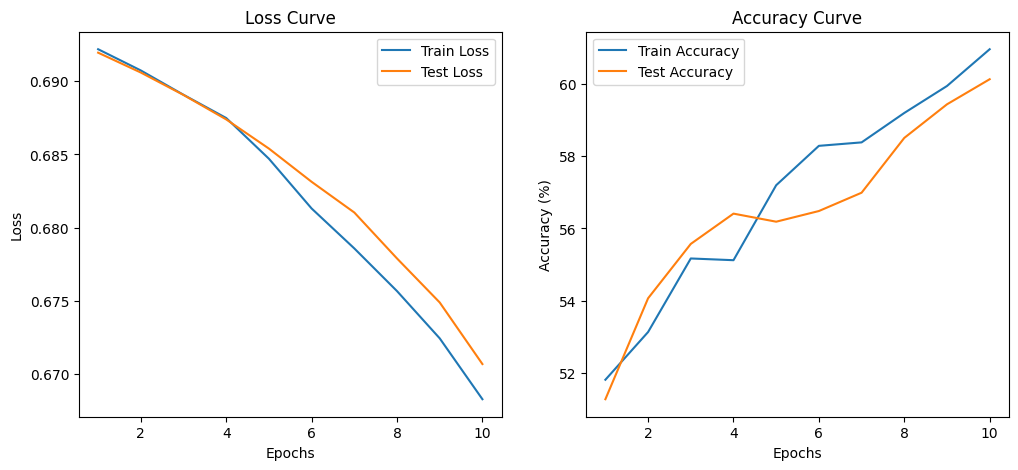

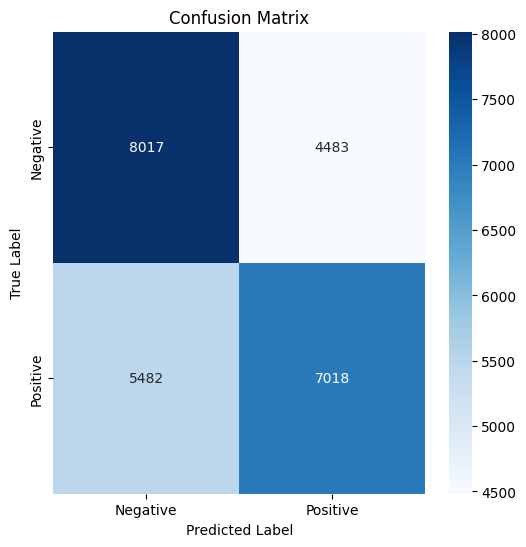


  Training with lowRank = 50
Epoch 1/10 | Train Loss: 0.6928 | Test Loss: 0.6920 | Train Accuracy: 50.99% | Test Accuracy: 50.77%
Epoch 2/10 | Train Loss: 0.6903 | Test Loss: 0.6896 | Train Accuracy: 54.09% | Test Accuracy: 54.71%
Epoch 3/10 | Train Loss: 0.6875 | Test Loss: 0.6872 | Train Accuracy: 56.60% | Test Accuracy: 55.48%
Epoch 4/10 | Train Loss: 0.6823 | Test Loss: 0.6797 | Train Accuracy: 58.52% | Test Accuracy: 59.50%
Epoch 5/10 | Train Loss: 0.6723 | Test Loss: 0.6702 | Train Accuracy: 60.65% | Test Accuracy: 60.33%
Epoch 6/10 | Train Loss: 0.6626 | Test Loss: 0.6637 | Train Accuracy: 61.35% | Test Accuracy: 60.57%
Epoch 7/10 | Train Loss: 0.6544 | Test Loss: 0.6555 | Train Accuracy: 62.50% | Test Accuracy: 62.46%
Epoch 8/10 | Train Loss: 0.6428 | Test Loss: 0.6417 | Train Accuracy: 64.24% | Test Accuracy: 63.91%
Epoch 9/10 | Train Loss: 0.6268 | Test Loss: 0.6273 | Train Accuracy: 65.75% | Test Accuracy: 65.56%
Epoch 10/10 | Train Loss: 0.6061 | Test Loss: 0.6083 | Train 

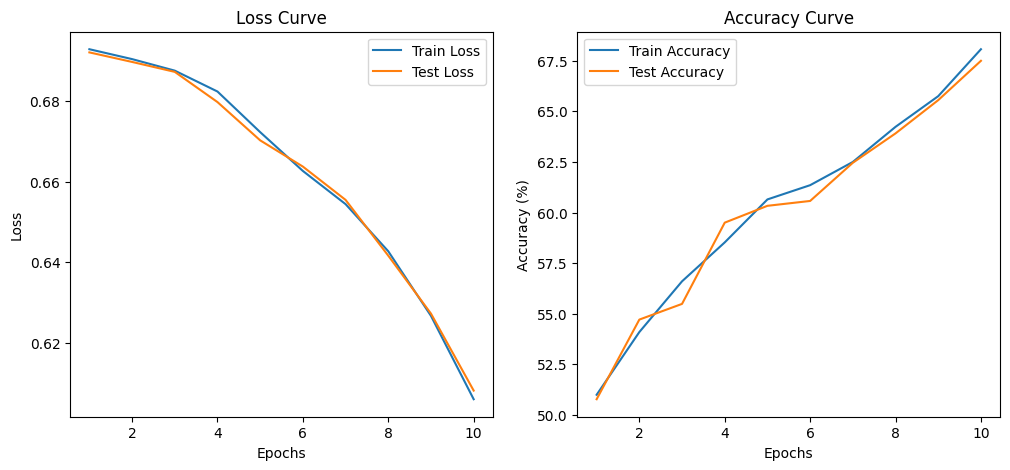

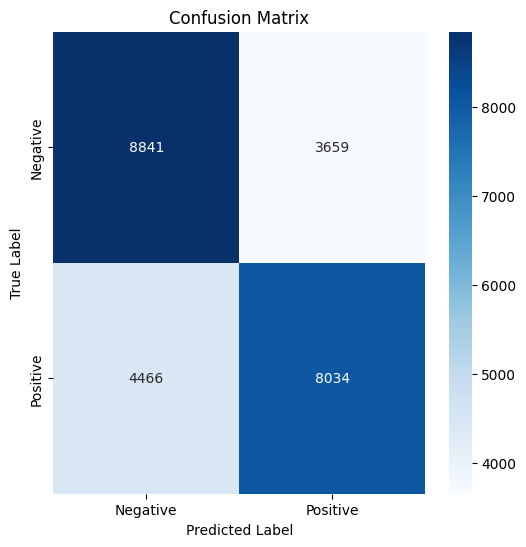


  Training with lowRank = 70
Epoch 1/10 | Train Loss: 0.6936 | Test Loss: 0.6922 | Train Accuracy: 50.23% | Test Accuracy: 51.65%
Epoch 2/10 | Train Loss: 0.6910 | Test Loss: 0.6906 | Train Accuracy: 53.24% | Test Accuracy: 53.76%
Epoch 3/10 | Train Loss: 0.6877 | Test Loss: 0.6861 | Train Accuracy: 55.73% | Test Accuracy: 56.04%
Epoch 4/10 | Train Loss: 0.6649 | Test Loss: 0.6461 | Train Accuracy: 61.78% | Test Accuracy: 64.34%
Epoch 5/10 | Train Loss: 0.6284 | Test Loss: 0.6256 | Train Accuracy: 65.41% | Test Accuracy: 65.59%
Epoch 6/10 | Train Loss: 0.6131 | Test Loss: 0.6130 | Train Accuracy: 66.48% | Test Accuracy: 67.05%
Epoch 7/10 | Train Loss: 0.5935 | Test Loss: 0.5843 | Train Accuracy: 68.34% | Test Accuracy: 69.06%
Epoch 8/10 | Train Loss: 0.5738 | Test Loss: 0.5728 | Train Accuracy: 69.97% | Test Accuracy: 70.16%
Epoch 9/10 | Train Loss: 0.5621 | Test Loss: 0.5585 | Train Accuracy: 70.95% | Test Accuracy: 71.23%
Epoch 10/10 | Train Loss: 0.5419 | Test Loss: 0.5398 | Train 

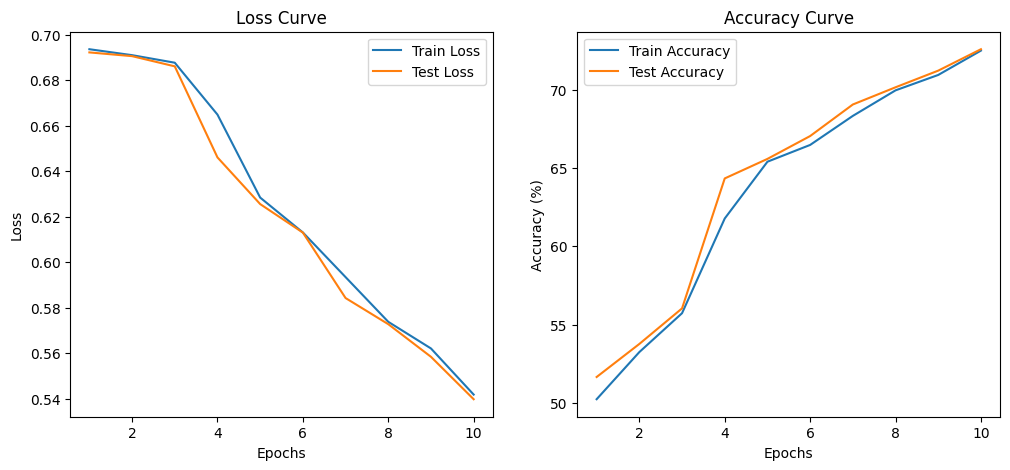

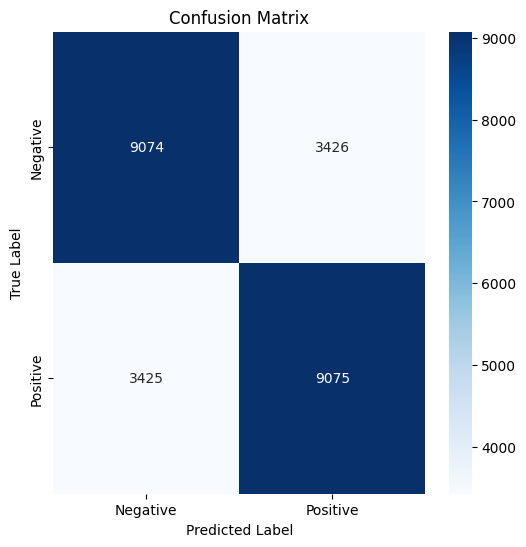


  Training with lowRank = 100
Epoch 1/10 | Train Loss: 0.6931 | Test Loss: 0.6916 | Train Accuracy: 50.78% | Test Accuracy: 53.12%
Epoch 2/10 | Train Loss: 0.6895 | Test Loss: 0.6864 | Train Accuracy: 54.13% | Test Accuracy: 55.54%
Epoch 3/10 | Train Loss: 0.6804 | Test Loss: 0.6630 | Train Accuracy: 58.04% | Test Accuracy: 62.82%
Epoch 4/10 | Train Loss: 0.6362 | Test Loss: 0.6262 | Train Accuracy: 64.51% | Test Accuracy: 65.74%
Epoch 5/10 | Train Loss: 0.6138 | Test Loss: 0.6156 | Train Accuracy: 66.61% | Test Accuracy: 66.50%
Epoch 6/10 | Train Loss: 0.6067 | Test Loss: 0.6077 | Train Accuracy: 67.31% | Test Accuracy: 67.26%
Epoch 7/10 | Train Loss: 0.5953 | Test Loss: 0.5912 | Train Accuracy: 68.35% | Test Accuracy: 68.72%
Epoch 8/10 | Train Loss: 0.5811 | Test Loss: 0.5787 | Train Accuracy: 69.44% | Test Accuracy: 69.72%
Epoch 9/10 | Train Loss: 0.5678 | Test Loss: 0.5705 | Train Accuracy: 70.66% | Test Accuracy: 70.54%
Epoch 10/10 | Train Loss: 0.5551 | Test Loss: 0.5572 | Train

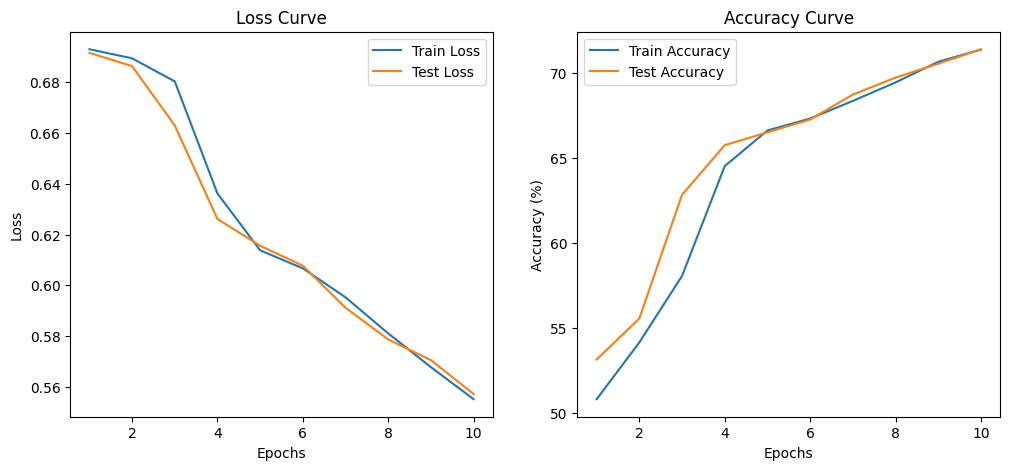

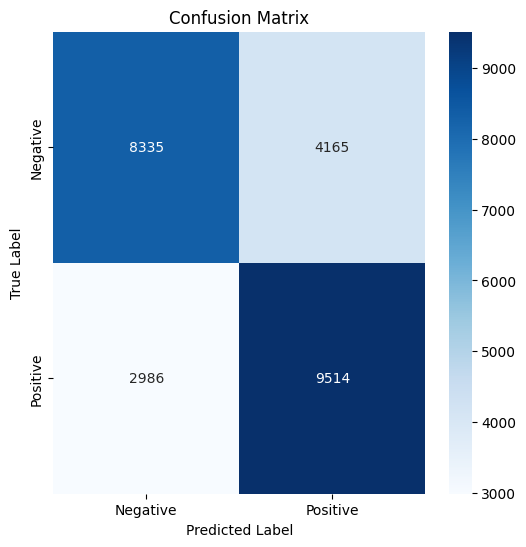

In [ ]:
lowRank_values = [1 , 5 , 10 , 15 , 20 , 35 , 50 , 70 , 100 ]
results = []

for lowRank in lowRank_values:
    print(f"\n  Training with lowRank = {lowRank}")

    model = TransformerClassifier(vocab_size, embed_dim, num_heads, ff_dim,
                                  num_layers, num_classes, max_seq_length, lowRank, dropout).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=1e-5)

    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    start_reserved_mem = torch.cuda.memory_reserved(device) if torch.cuda.is_available() else 0
    start_max_mem = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0
    start_time = time.time()

    # Train the model
    train_losses, test_losses, train_accuracies, test_accuracies = train_model(
        model, train_loader, test_loader, criterion, optimizer, num_epochs, device=device)

    end_reserved_mem = torch.cuda.memory_reserved(device) if torch.cuda.is_available() else 0
    end_max_mem = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0
    total_time = time.time() - start_time

    memory_usage = (end_reserved_mem - start_reserved_mem) / (1024 ** 2)
    final_accuracy = test_accuracies[-1]
    accuracy_per_time = final_accuracy / (total_time + 1e-6)

    results.append({
        "lowRank": lowRank,
        "accuracy": final_accuracy,
        "training_time": total_time,
        "memory_usage": memory_usage,
        "num_parameters": total_params,
        "accuracy_per_time": accuracy_per_time
    })


    _, _, all_labels, all_preds = evaluate_model(model, test_loader, criterion, device)
    plot_learning_curve(train_losses, test_losses, train_accuracies, test_accuracies)
    plot_confusion_matrix(all_labels, all_preds, class_names=["Negative", "Positive"])

In [ ]:
df_results = pd.DataFrame(results)
df_results


,lowRank,accuracy,training_time,memory_usage,num_parameters,accuracy_per_time
0,1,59.072,230.724355,2884.0,4040069,0.256028
1,5,55.984,231.271435,2340.0,4043213,0.242071
2,10,56.584,231.016393,2340.0,4047278,0.244935
3,15,63.456,232.472731,2338.0,4051493,0.272961
4,20,61.288,231.552556,2272.0,4055858,0.264683
5,35,60.140,232.191863,2338.0,4069853,0.259010
6,50,67.500,232.361583,2338.0,4085198,0.290496
7,70,72.596,232.272690,2304.0,4107758,0.312546
8,100,71.396,232.093247,2338.0,4146098,0.307618


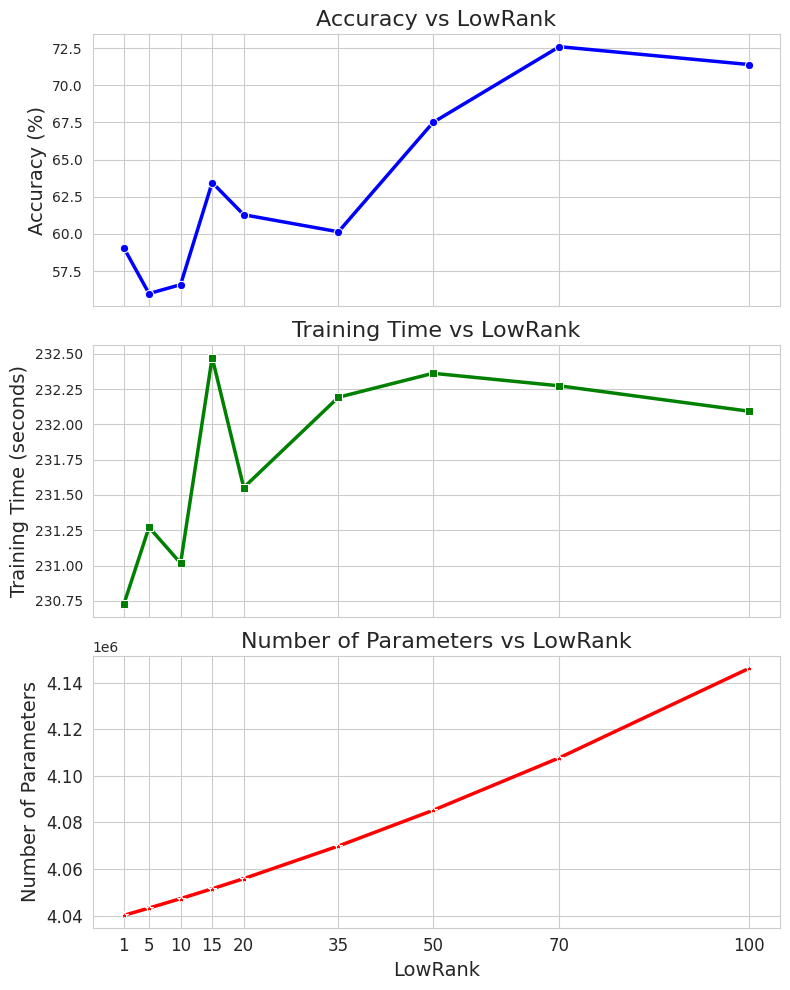

In [35]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

sns.lineplot(ax=axes[0], x=df_results["lowRank"], y=df_results["accuracy"],
             marker="o", linewidth=2.5, color="blue")
axes[0].set_ylabel("Accuracy (%)", fontsize=14)
axes[0].set_title("Accuracy vs LowRank", fontsize=16)
plt.xticks(df_results["lowRank"], fontsize=12)
plt.yticks(fontsize=12)


sns.lineplot(ax=axes[1], x=df_results["lowRank"], y=df_results["training_time"],
             marker="s", linewidth=2.5, color="green")
axes[1].set_ylabel("Training Time (seconds)", fontsize=14)
axes[1].set_title("Training Time vs LowRank", fontsize=16)
plt.xticks(df_results["lowRank"], fontsize=12)
plt.yticks(fontsize=12)


sns.lineplot(ax=axes[2], x=df_results["lowRank"], y=df_results["num_parameters"],
             marker="*", linewidth=2.5, color="red")
axes[2].set_xlabel("LowRank", fontsize=14)
axes[2].set_ylabel("Number of Parameters", fontsize=14)
axes[2].set_title("Number of Parameters vs LowRank", fontsize=16)
plt.xticks(df_results["lowRank"], fontsize=12)
plt.yticks(fontsize=12)


plt.tight_layout()

plt.show()

